In [1]:
# ======================================================================
# CAPÍTULO 4 - IMPORTS, ESTILO E CORES
# ======================================================================

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuração visual profissional
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['lines.markersize'] = 8

CORES = {
    'MRT': '#E74C3C',
    'T2F': '#3498DB',
    'Fase_A': '#00CED1',
    'Fase_B': '#FF6347',
    'Fase_C': '#32CD32',
    'I0': '#4169E1',
    'I1': '#228B22',
    'I2': '#8B008B'
}

In [2]:
pasta_entrada = Path("C:/Users/Leonardo Felipe/OneDrive/Coisas_Leonardo/gits/CurtosT2F/T2F_MATLAB/NovoArtigoPowerDelivery34bus/NovoModeloQualificacao/Teste_Novo_Sem_Terra_10/Processados_HDF5/")

In [3]:
arquivos = sorted(pasta_entrada.glob("*.mat"))  # ou "*_py.mat"

In [4]:
barras = ["800", "816", "818", "820", "822"]  # ajuste se tiver mais
# dicionário mestre: dados_por_arquivo["nome.mat"]["I_822"]["raw"] -> array N x 3
dados_por_arquivo = {}
resultados = []
linhas = []
proc_por_arquivo_barra = {}   # chave: (arquivo, barra)

In [5]:
for arq in arquivos:
    with h5py.File(arq, "r") as f:
        if "t" not in f.keys():
            continue
        
        nome = arq.name
        dados_por_arquivo[nome] = {}
        
        t = np.array(f["t"]).flatten()
        m1 = float(f["m1"][()]) if "m1" in f.keys() else None
        
        dados_por_arquivo[nome]["t"] = t
        dados_por_arquivo[nome]["m1"] = m1
        
        for barra in barras:
            ni = f"I_{barra}_raw" if f"I_{barra}_raw" in f.keys() else None
            nv = f"V_{barra}_raw" if f"V_{barra}_raw" in f.keys() else None
            
            if ni is not None:
                I = np.array(f[ni])
                if I.ndim == 1:
                    I = np.column_stack([I]*3)
                elif I.shape[0] == 3 and I.shape[1] > 3:
                    I = I.T
                dados_por_arquivo[nome][f"I_{barra}"] = I
            
            if nv is not None:
                V = np.array(f[nv])
                if V.ndim == 1:
                    V = np.column_stack([V]*3)
                elif V.shape[0] == 3 and V.shape[1] > 3:
                    V = V.T
                dados_por_arquivo[nome][f"V_{barra}"] = V

print("Arquivos carregados:", len(dados_por_arquivo))

Arquivos carregados: 136


In [13]:
class BarraProcessor:
    def __init__(self, t, v_raw, i_raw, freq=60):
        t = np.asarray(t, dtype=float).flatten()
        v_raw = np.asarray(v_raw, dtype=float)
        i_raw = np.asarray(i_raw, dtype=float)

        self.t = t
        self.freq = float(freq)

        self.v_raw = self._fix_shape(v_raw, len(t)) / np.sqrt(3)
        self.i_raw = self._fix_shape(i_raw, len(t))

        L = min(len(self.t), len(self.v_raw), len(self.i_raw))
        if L < 10:
            raise ValueError("Dados insuficientes.")
        self.t = self.t[:L]
        self.v_raw = self.v_raw[:L]
        self.i_raw = self.i_raw[:L]

        dt = self.t[1] - self.t[0]
        self.dt = float(dt)
        self.fs = 1.0 / self.dt
        self.samples = max(1, int(self.fs / self.freq))

        # RMS e Clarke
        self.v_rms = self._rms(self.v_raw)
        self.i_rms = self._rms(self.i_raw)
        self.i_clarke = self._clarke(self.i_raw)

        # Componentes de sequência (Fortescue)
        self.I0, self.I1, self.I2 = self._seq_components(self.i_raw)   # magnitudes
        # se quiser acessar como array N x 3 também:
        self.i_seq = np.stack([self.I0, self.I1, self.I2], axis=1)

    def _fix_shape(self, mat, N):
        if mat.ndim == 1:
            col = mat.flatten()
            return np.stack([col, col, col], axis=1)
        if mat.ndim == 2:
            if mat.shape[0] == 3 and mat.shape[1] > 3:
                return mat.T
            if mat.shape[1] == 3:
                return mat
        return np.zeros((N, 3))

    def _rms(self, x):
        return np.sqrt(np.abs(
            scipy.ndimage.uniform_filter1d(x**2, self.samples, axis=0)
        ))

    def _clarke(self, abc):
        a, b, c = abc[:,0], abc[:,1], abc[:,2]
        alpha = (2*a - b - c)/3.0
        beta  = (b - c)/np.sqrt(3.0)
        return {"alpha": alpha, "beta": beta}

    def _seq_components(self, x):
        """
        Retorna I0, I1, I2 como magnitudes ao longo do tempo,
        calculadas pela transformada de Fortescue.
        """
        rot = np.exp(-1j*2*np.pi*self.freq*self.t)
        ph = np.zeros_like(x, dtype=complex)
        for k in range(3):
            ph[:,k] = scipy.ndimage.uniform_filter1d(
                x[:,k]*rot, self.samples
            ) * np.sqrt(2)

        a = np.exp(1j*2*np.pi/3)
        I0 = (ph[:,0] +      ph[:,1] +      ph[:,2]) / 3.0
        I1 = (ph[:,0] +  a * ph[:,1] + a**2*ph[:,2]) / 3.0
        I2 = (ph[:,0] + a**2*ph[:,1] +  a *ph[:,2]) / 3.0

        return np.abs(I0), np.abs(I1), np.abs(I2)


In [14]:
for nome_arq, dados in dados_por_arquivo.items():
    t = dados["t"]
    for barra in barras:
        chave_I = f"I_{barra}"
        chave_V = f"V_{barra}"
        if chave_I in dados and chave_V in dados:
            proc = BarraProcessor(t, dados[chave_V], dados[chave_I])
            proc_por_arquivo_barra[(nome_arq, barra)] = proc

print("Total de combinações arquivo-barra processadas:",
      len(proc_por_arquivo_barra))

Total de combinações arquivo-barra processadas: 544


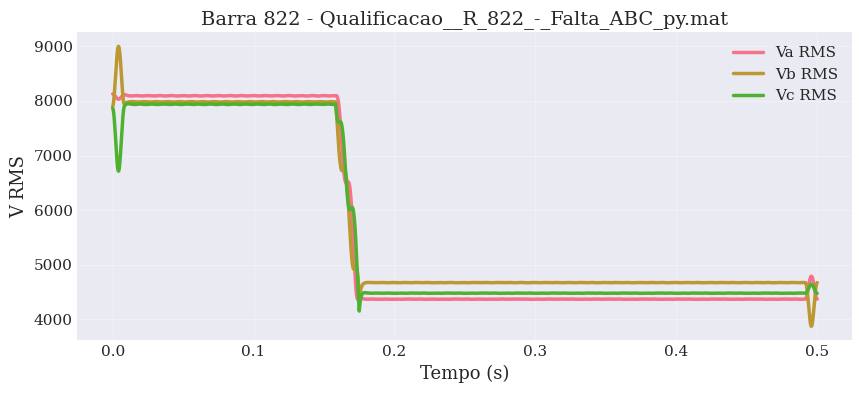

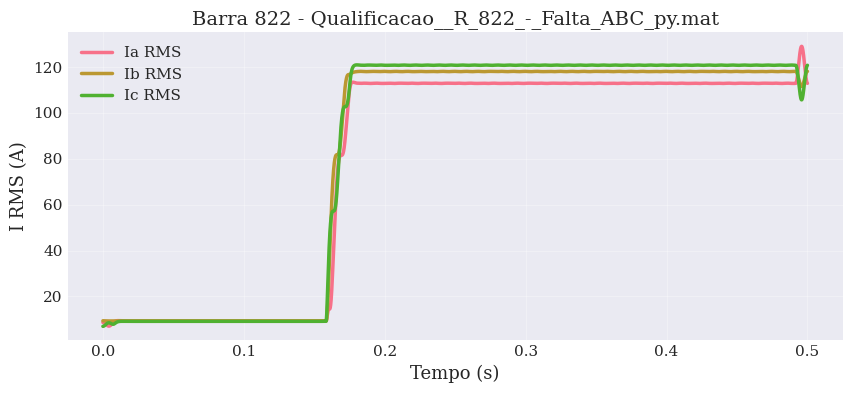

In [19]:
nome = "Qualificacao__R_822_-_Falta_ABC_py.mat"
barra = "822"

p = proc_por_arquivo_barra[(nome, barra)]

plt.figure(figsize=(10,4))
plt.plot(p.t, p.v_rms[:,0], label="Va RMS")
plt.plot(p.t, p.v_rms[:,1], label="Vb RMS")
plt.plot(p.t, p.v_rms[:,2], label="Vc RMS")
plt.xlabel("Tempo (s)")
plt.ylabel("V RMS")
plt.title(f"Barra {barra} - {nome}")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(p.t, p.i_rms[:,0], label="Ia RMS")
plt.plot(p.t, p.i_rms[:,1], label="Ib RMS")
plt.plot(p.t, p.i_rms[:,2], label="Ic RMS")
plt.xlabel("Tempo (s)")
plt.ylabel("I RMS (A)")
plt.title(f"Barra {barra} - {nome}")
plt.grid(True)
plt.legend()
plt.show()


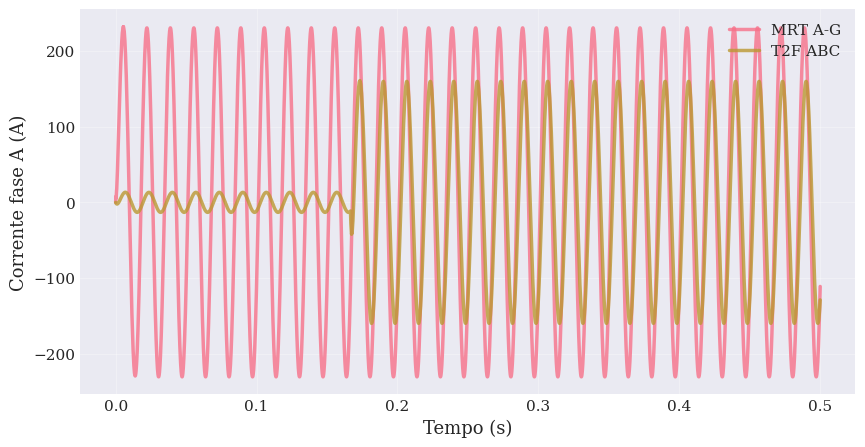

In [20]:
nome_mrt = "MRT__A_822_-_Falta_A_py.mat"
nome_t2f = "Qualificacao__R_822_-_Falta_ABC_py.mat"

t_mrt = dados_por_arquivo[nome_mrt]["t"]
I_mrt = dados_por_arquivo[nome_mrt]["I_822"][:,0]

t_t2f = dados_por_arquivo[nome_t2f]["t"]
I_t2f = dados_por_arquivo[nome_t2f]["I_822"][:,0]

plt.figure(figsize=(10,5))
plt.plot(t_mrt, I_mrt, label="MRT A-G", alpha=0.8)
plt.plot(t_t2f, I_t2f, label="T2F ABC", alpha=0.8)
plt.xlabel("Tempo (s)")
plt.ylabel("Corrente fase A (A)")
plt.grid(True)
plt.legend()
plt.show()

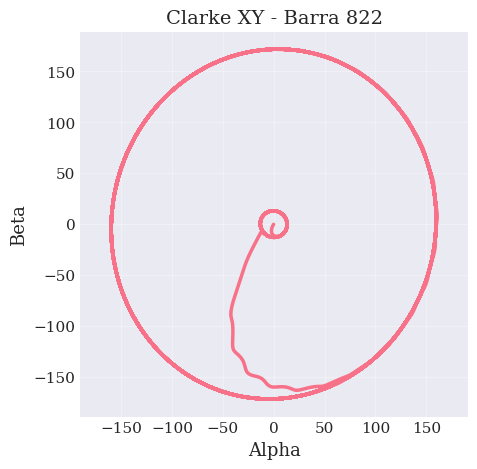

In [21]:
plt.figure(figsize=(5,5))
plt.plot(p.i_clarke["alpha"], p.i_clarke["beta"])
plt.xlabel("Alpha")
plt.ylabel("Beta")
plt.title(f"Clarke XY - Barra {barra}")
plt.grid(True)
plt.axis("equal")
plt.show()


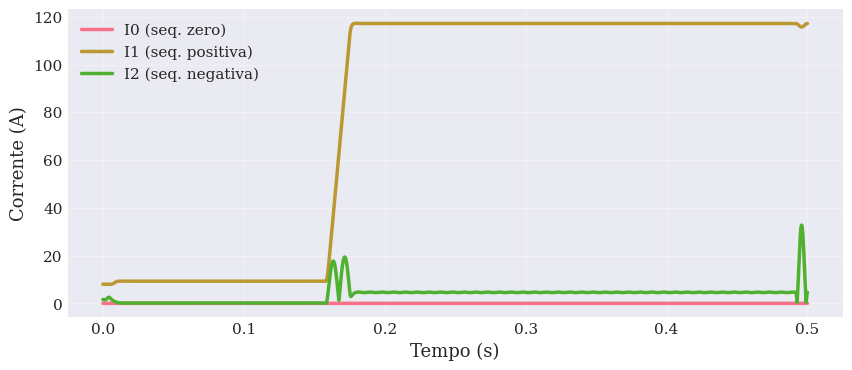

In [22]:
# gráfico das sequências zero, positiva e negativa
plt.figure(figsize=(10,4))
plt.plot(p.t, p.I0, label="I0 (seq. zero)")
plt.plot(p.t, p.I1, label="I1 (seq. positiva)")
plt.plot(p.t, p.I2, label="I2 (seq. negativa)")
plt.xlabel("Tempo (s)")
plt.ylabel("Corrente (A)")
plt.grid(True)
plt.legend()
plt.show()

In [12]:
nome = "MRT__A_822_-_Falta_A_py.mat"

barras_disponiveis = [k[1] for k in proc_por_arquivo_barra.keys() if k[0] == nome]
print("Barras processadas nesse arquivo:", barras_disponiveis)

Barras processadas nesse arquivo: ['800', '818', '820', '822']
